In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

PROCESSED = Path("../data/processed")

fact = pd.read_csv(PROCESSED / "fact_exported.csv")

table = (
    fact.groupby("CO_ANO", as_index=False)["VL_FOB"]
    .sum()
)

official_exports = {
    2021: 280814577460,
    2022: 334136038220,
    2023: 339695766008,
    2024: 337046161710,
    2025: 348278462500
}

table["OFFICIAL_EXPORT_USD"] = table["CO_ANO"].map(official_exports)

table["VL_FOB"] = table["VL_FOB"].map(lambda x: f"${x:,.0f}")
table["OFFICIAL_EXPORT_USD"] = table["OFFICIAL_EXPORT_USD"].map(lambda x: f"${x:,.0f}")

display(HTML("<h1>Brazilian Exports by Year (USD)</h1>"))

table

,CO_ANO,VL_FOB,OFFICIAL_EXPORT_USD
0,2021,"$280,814,577,460","$280,814,577,460"
1,2022,"$334,136,038,220","$334,136,038,220"
2,2023,"$339,695,766,008","$339,695,766,008"
3,2024,"$337,046,161,710","$337,046,161,710"
4,2025,"$348,278,462,500","$348,278,462,500"


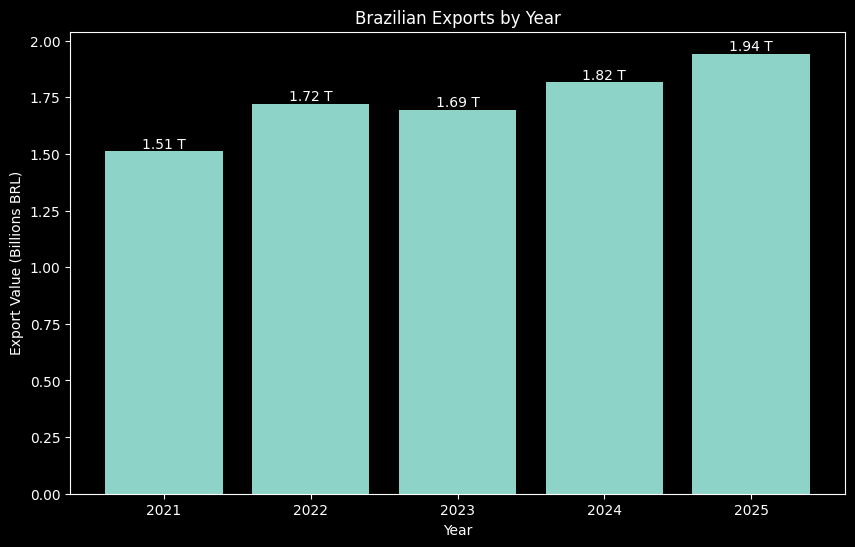

In [40]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

exports = fact.groupby("CO_ANO")["VL_FOB_BRL"].sum() / 1e12

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(exports.index.astype(str), exports.values)
display(HTML("<h1>Brazilian Exports by Year (BRL)</h1>"))

ax.set_title("Brazilian Exports by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (Billions BRL)")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f} T",
        ha='center',
        va='bottom'
    )

plt.show()

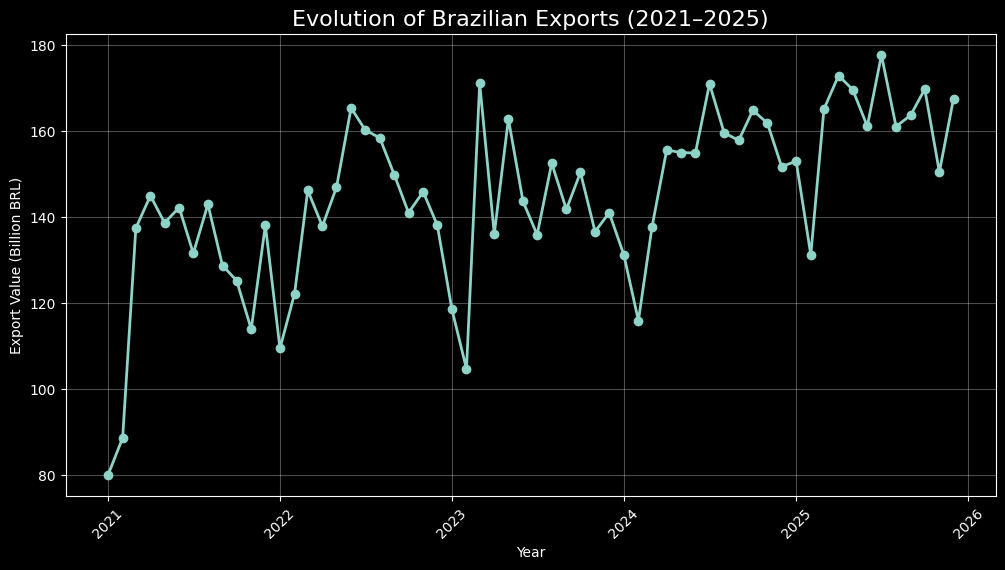

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path("../data/processed")

fact = pd.read_csv(PROCESSED / "fact_exported.csv")

plt.style.use("dark_background")

monthly = (
    fact.groupby(["CO_ANO","CO_MES"])["VL_FOB_BRL"]
    .sum()
    .reset_index()
)

monthly["date"] = pd.to_datetime(
    monthly["CO_ANO"].astype(str) + "-" +
    monthly["CO_MES"].astype(str)
)

monthly["exports_billion"] = monthly["VL_FOB_BRL"] / 1e9

fig, ax = plt.subplots(figsize=(12,6))

display(HTML("<h1>Brazilian Exports by Month (BRL)</h1>"))

ax.plot(
    monthly["date"],
    monthly["exports_billion"],
    marker="o",
    linewidth=2
)

ax.set_title("Evolution of Brazilian Exports (2021–2025)", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (Billion BRL)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

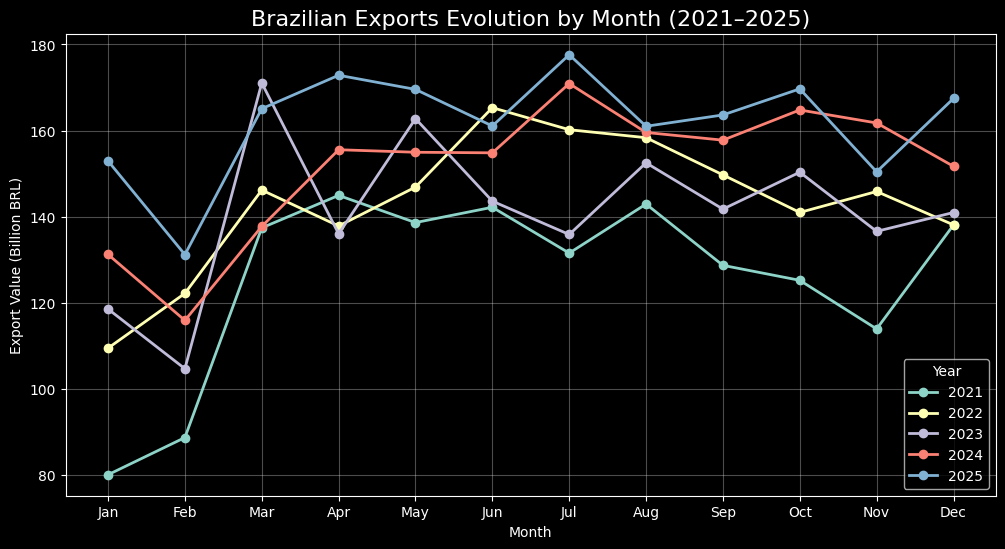

In [48]:
PROCESSED = Path("../data/processed")

fact = pd.read_csv(PROCESSED / "fact_exported.csv")

plt.style.use("dark_background")

monthly = (
    fact.groupby(["CO_ANO","CO_MES"])["VL_FOB_BRL"]
    .sum()
    .reset_index()
)

monthly["exports_brl_billion"] = monthly["VL_FOB_BRL"] / 1e9

pivot = monthly.pivot(
    index="CO_MES",
    columns="CO_ANO",
    values="exports_brl_billion"
)

display(HTML("<h1>Brazilian Exports by Month (BRL)</h1>"))

fig, ax = plt.subplots(figsize=(12,6))

pivot.plot(
    ax=ax,
    marker="o",
    linewidth=2
)

months = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

ax.set_xticks(range(1,13))
ax.set_xticklabels(months)

ax.set_title("Brazilian Exports Evolution by Month (2021–2025)", fontsize=16)
ax.set_xlabel("Month")
ax.set_ylabel("Export Value (Billion BRL)")

ax.legend(title="Year")

plt.grid(alpha=0.3)

plt.show()

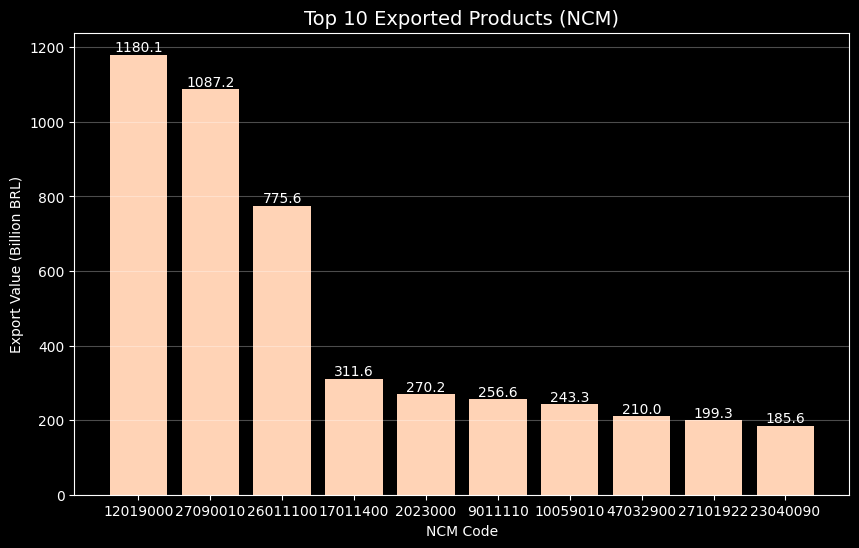

In [ ]:
plt.style.use("dark_background")

top_products = (
    fact.groupby("CO_NCM")["VL_FOB_BRL"]
    .sum()
    .sort_values(ascending=False)
    .head(10) / 1e9
)

display(HTML("<h1>Top 10 Exported Products (NCM)</h1>"))

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    top_products.index.astype(str),
    top_products.values,
    color="#FFD3B6"
)

ax.set_title("Top 10 Exported Products (NCM)", fontsize=14)
ax.set_ylabel("Export Value (Billion BRL)")
ax.set_xlabel("NCM Code")

plt.xticks(rotation=360)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()